<a href="https://colab.research.google.com/github/pondpatipatpankaew/GE338/blob/main/LAB/Lab3/lab3_comparison_6606520168_%E0%B8%9B%E0%B8%8F%E0%B8%B4%E0%B8%9E%E0%B8%B1%E0%B8%92%E0%B8%99%E0%B9%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================
# 0) Setup Folder & Imports
# =========================
!pip install rasterio scikit-learn matplotlib seaborn -q

import rasterio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# =========================
# 2) Load Sentinel-2 Image
# =========================
tif_path = '/content/drive/MyDrive/GE338/LAB3/TIF/S2_allbands.tif'
img_src = rasterio.open(tif_path)

# อ่าน Bands
blue = img_src.read(2)
green = img_src.read(3)
red = img_src.read(4)
nir = img_src.read(8)

# คำนวณ Spectral Indices
ndvi = (nir - red) / (nir + red + 1e-10)
ndwi = (green - nir) / (green + nir + 1e-10)

# Stack bands + indices
stack = np.stack([blue, green, red, nir, ndvi, ndwi], axis=-1)
print("Image stack shape:", stack.shape)

# =========================
# 3) Load Label
# =========================
label_path = '/content/drive/MyDrive/GE338/label_5class_final.tif'
label_src = rasterio.open(label_path)
labels = label_src.read(1)

print("Unique classes (original):", np.unique(labels))

# Filter target classes
valid_classes = [0, 1, 4, 6, 7]  # water, trees, crops, built-up, bare
mask_valid = np.isin(labels, valid_classes)
labels = np.where(mask_valid, labels, -1)
print("Classes after filter:", np.unique(labels))

# =========================
# 4) Resize label ให้ตรงกับ stack
# =========================
from skimage.transform import resize
labels_resized = resize(
    labels,
    (stack.shape[0], stack.shape[1]),
    order=0,
    preserve_range=True,
    anti_aliasing=False
).astype(labels.dtype)

# =========================
# 5) Prepare X, y
# =========================
X = stack.reshape(-1, stack.shape[-1])
y = labels_resized.flatten()

# Remove background
mask = y != -1
X = X[mask]
y = y[mask]

print("Prepared X, y shapes:", X.shape, y.shape)

# Encode labels (0-4)
le = LabelEncoder()
y = le.fit_transform(y)
print("Encoded classes:", np.unique(y))

# =========================
# 6) Train/Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Image stack shape: (2139, 2500, 6)
Unique classes (original): [0 1 4 6 7]
Classes after filter: [0 1 4 6 7]
Prepared X, y shapes: (5347500, 6) (5347500,)
Encoded classes: [0 1 2 3 4]
Training data: (4278000, 6)
Testing data: (1069500, 6)


In [6]:
# =========================
# 1) Train Random Forest
# =========================
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Random Forest trained")

# =========================
# 2) Train KMeans (Unsupervised)
# =========================
# ใช้ sample เล็กเพื่อลด RAM
np.random.seed(42)
idx_sample = np.random.choice(len(X), 100000, replace=False)
X_sample = X[idx_sample]

kmeans = KMeans(
    n_clusters=len(np.unique(y)),  # จำนวน class
    n_init=10,
    random_state=42
)
kmeans.fit(X_sample)
print("KMeans trained ✅")

Random Forest trained
KMeans trained ✅


In [7]:
# =========================
# Predict RF
# =========================
y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_kappa = cohen_kappa_score(y_test, y_pred_rf)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)
rf_cm = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_acc)
print("Random Forest Kappa:", rf_kappa)

# =========================
# Predict KMeans (approximate)
# =========================
# ต้อง align ขนาดกับ y_test
kmeans_pred_test = kmeans.predict(X_test)
km_acc = accuracy_score(y_test, kmeans_pred_test)
km_kappa = cohen_kappa_score(y_test, kmeans_pred_test)
km_report = classification_report(y_test, kmeans_pred_test, output_dict=True)
km_cm = confusion_matrix(y_test, kmeans_pred_test)

print("KMeans Accuracy:", km_acc)
print("KMeans Kappa:", km_kappa)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest Accuracy: 0.8319074333800841
Random Forest Kappa: 0.6513927840890221
KMeans Accuracy: 0.4208424497428705
KMeans Kappa: 0.18235437706273372


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest Accuracy: 0.8319
Random Forest Kappa: 0.6514


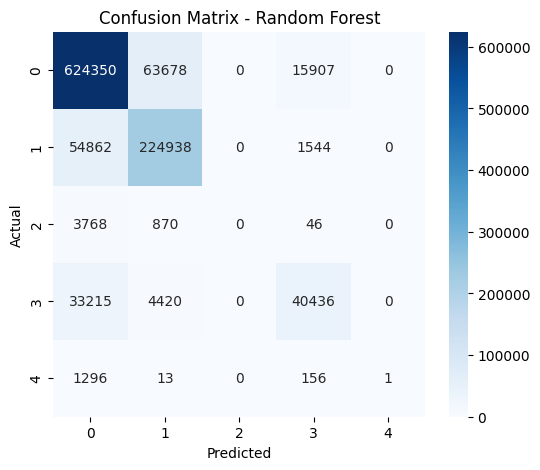

In [8]:
# =========================
#Evaluate Random Forest
# =========================
y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_kappa = cohen_kappa_score(y_test, y_pred_rf)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)

print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"Random Forest Kappa: {rf_kappa:.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

KMeans Accuracy: 0.4208
KMeans Kappa: 0.1824


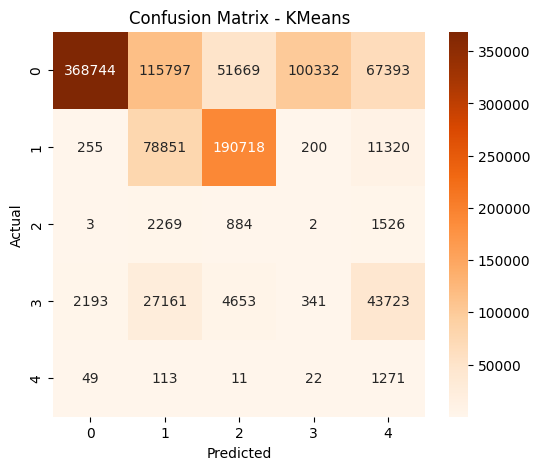

In [9]:
# =========================
# Evaluate KMeans
# =========================
# ต้อง align ขนาดก่อน
kmeans_pred_test = kmeans.predict(X_test)

km_acc = accuracy_score(y_test, kmeans_pred_test)
km_kappa = cohen_kappa_score(y_test, kmeans_pred_test)
km_report = classification_report(y_test, kmeans_pred_test, output_dict=True)

print(f"KMeans Accuracy: {km_acc:.4f}")
print(f"KMeans Kappa: {km_kappa:.4f}")

# Confusion Matrix
cm_km = confusion_matrix(y_test, kmeans_pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm_km, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - KMeans")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

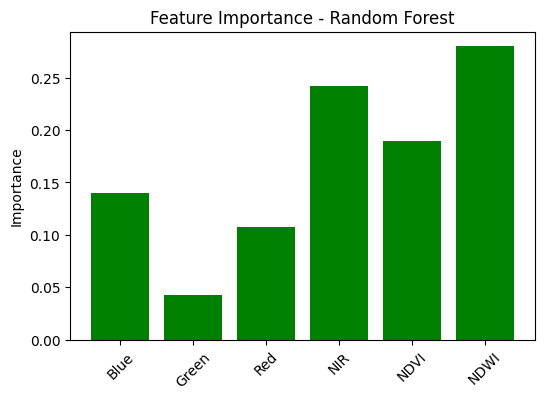

Blue: 0.1398
Green: 0.0422
Red: 0.1073
NIR: 0.2417
NDVI: 0.1893
NDWI: 0.2797


In [10]:
# =========================
# Feature Importance (RF)
# =========================
features = ['Blue', 'Green', 'Red', 'NIR', 'NDVI', 'NDWI']
importances = rf.feature_importances_

plt.figure(figsize=(6,4))
plt.bar(features, importances, color='green')
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

# สรุป Feature สำคัญ
for f, imp in zip(features, importances):
    print(f"{f}: {imp:.4f}")

In [11]:
# =========================
# Summary Table
# =========================
summary = pd.DataFrame({
    "Model": ["Random Forest", "KMeans"],
    "Accuracy": [rf_acc, km_acc],
    "Kappa": [rf_kappa, km_kappa]
})

display(summary)

,Model,Accuracy,Kappa
0,Random Forest,0.831907,0.651393
1,KMeans,0.420842,0.182354


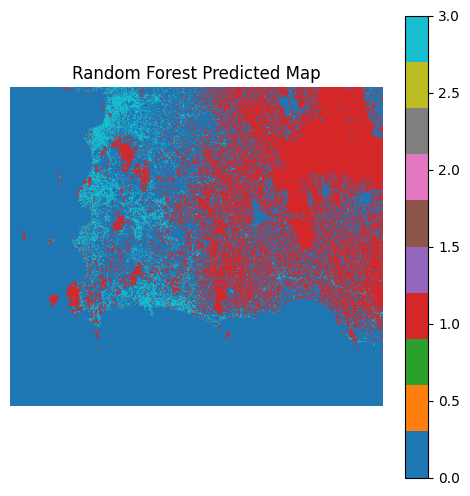

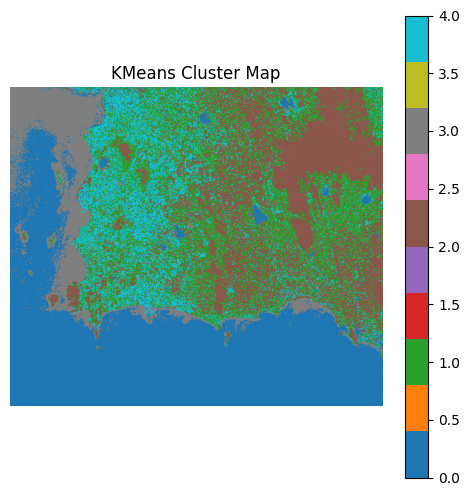

In [12]:
# =========================
# Predict Full Map
# =========================
# Random Forest
y_full_rf = rf.predict(X)

pred_map_rf = np.zeros(labels_resized.shape)
pred_map_rf.reshape(-1)[mask] = y_full_rf

plt.figure(figsize=(6,6))
plt.imshow(pred_map_rf[::5, ::5], cmap='tab10')
plt.colorbar()
plt.title("Random Forest Predicted Map")
plt.axis('off')
plt.show()

# KMeans
y_full_km = kmeans.predict(X)

pred_map_km = np.zeros(labels_resized.shape)
pred_map_km.reshape(-1)[mask] = y_full_km

plt.figure(figsize=(6,6))
plt.imshow(pred_map_km[::5, ::5], cmap='tab10')
plt.colorbar()
plt.title("KMeans Cluster Map")
plt.axis('off')
plt.show()

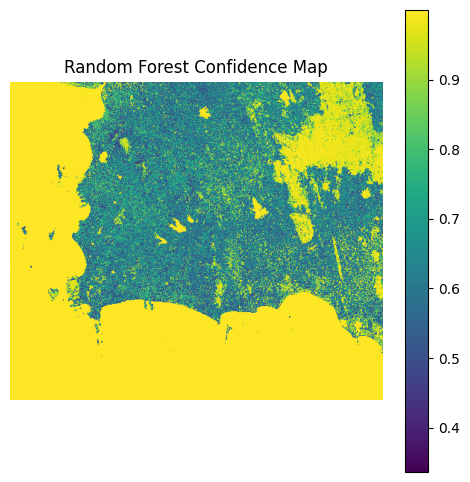

In [15]:
# =========================
# Confidence Map (RF)
# =========================
probs_rf = rf.predict_proba(X)
confidence = np.max(probs_rf, axis=1)

conf_map = np.zeros(labels_resized.shape)
conf_map.reshape(-1)[mask] = confidence

plt.figure(figsize=(6,6))
plt.imshow(conf_map[::5, ::5], cmap='viridis')
plt.colorbar()
plt.title("Random Forest Confidence Map")
plt.axis('off')
plt.show()